In [2]:
from functions import extract_surface_lines_np
import numpy as np
import tensorflow as tf

In [3]:
# test function
with open('models/cone/a cone with a 10.00mm diameter and a 20.00mm height.brep', 'r', encoding='utf-8') as f:
    b = f.read()
    print(extract_surface_lines_np(b))

[ 0.          0.         20.          0.          0.         -1.
 -1.          0.         -0.          0.          1.          0.
  0.          0.24497867  0.          0.          0.          0.
  0.         -1.         -1.          0.         -0.          0.
  1.          0.        ]


In [4]:
import os

shapes = ['cone', 'cube', 'cylinder', 'sphere', 'pipe', 'round_plate', 'rectangular_plate']

file_list = [os.listdir('models/' + shape) for shape in shapes]

X = []
y = []

for shape in shapes:
    y.append([shape]*len(os.listdir('models/' + shape)))

# flatten
file_list = [item for items in file_list for item in items]
y = [item for items in y for item in items]

for i in range(0, len(file_list)):
    with open('models/' + y[i] + '/' + file_list[i], 'r', encoding='utf-8') as f:
        brep_str = f.read()
        X.append(extract_surface_lines_np(brep_str))

In [5]:
from numpy import float32
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

maxlen = 1024
X_pad = pad_sequences(X, maxlen=maxlen, dtype='float32', padding='post', truncating='post', value=0.0)
X_pad = X_pad[..., None]

num_outputs = len(shapes)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_arr = np.asarray(y_encoded, dtype='int32')

X_train, X_test, y_train, y_test = train_test_split(X_pad, y_arr, test_size=0.2, random_state=3)

model = models.Sequential([
    layers.Input(shape=(maxlen, 1)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_outputs, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
model_trained = model.fit(X_train, y_train, epochs=10, validation_split=0.1, batch_size=64)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5913 - loss: 1.4527 - val_accuracy: 0.9643 - val_loss: 0.7441
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9980 - loss: 0.5713 - val_accuracy: 1.0000 - val_loss: 0.4167
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.3117 - val_accuracy: 1.0000 - val_loss: 0.2685
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.1964 - val_accuracy: 1.0000 - val_loss: 0.1775
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.1310 - val_accuracy: 1.0000 - val_loss: 0.1212
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0929 - val_accuracy: 1.0000 - val_loss: 0.0865
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0693 - val_accuracy: 1.0000 - val_loss: 0.0658
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0533 - val_accuracy: 1.0000 - val_loss: 0.0525
Epoch 9

In [7]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

In [8]:
# Predictions for neural network
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [9]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 1.0000


In [10]:
# Classification Report
report = classification_report(y_test, y_pred_classes, target_names=shapes)
print("\nClassification Report:")
print(report)


Classification Report:
                   precision    recall  f1-score   support

             cone       1.00      1.00      1.00        16
             cube       1.00      1.00      1.00        25
         cylinder       1.00      1.00      1.00        19
           sphere       1.00      1.00      1.00        23
             pipe       1.00      1.00      1.00        13
      round_plate       1.00      1.00      1.00        15
rectangular_plate       1.00      1.00      1.00        29

         accuracy                           1.00       140
        macro avg       1.00      1.00      1.00       140
     weighted avg       1.00      1.00      1.00       140



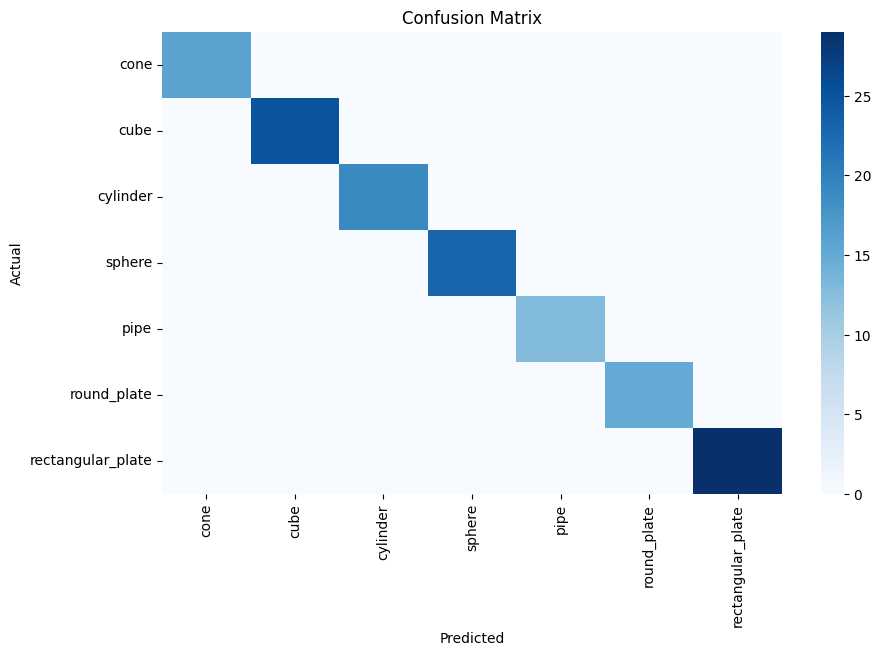

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
conf_mat = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 6))
sns.heatmap(conf_mat, annot=False, cmap='Blues', fmt='d',
            xticklabels=shapes,
            yticklabels=shapes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [11]:
#training time
import time

start_time = time.time()
_ = model.fit(X_train, y_train, epochs=10, validation_split=0.1, batch_size=64, verbose=0)
end_time = time.time()

train_time = end_time - start_time
print("Training time (seconds):", train_time)
print("Training time per epoch (seconds):", train_time / 10)

Training time (seconds): 0.33397388458251953
Training time per epoch (seconds): 0.03339738845825195


In [12]:
#inference time
import time

start_time = time.time()
_ = model.predict(X_test, verbose=0)
end_time = time.time()

inference_time = end_time - start_time
print("Inference time for full test set:", inference_time, "seconds")

Inference time for full test set: 0.04009294509887695 seconds


In [13]:
#model size and parameters
model.summary()

total_params = model.count_params()
print("Total trainable parameters:", total_params)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 396,311 (1.51 MB)

 Trainable params: 132,103 (516.03 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 264,208 (1.01 MB)

Total trainable parameters: 132103
